# Работа по теме "Численное прогнозирование"

## Описание

Работа предполагает самостоятельное исследование данных и построение регрессионных моделей.

Основная задача работы - научиться работать с методами численного прогнозирования, настраивать и отбирать лучшие модели.

Предлагается один набор данных.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- верно проведена обработка категориальных данных;
- рассмотрено не менее трех различных методов регрессии;
- создаваемые модели настроены для получения наилучших результатов;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы.

В результате необходимо получить наилучшую модель численного прогнозирования, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс выбора и настройки моделей.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Анализ доходов домохозяйств

Набор данных `household_income.csv`.

Описание данных:
- Age: Age of the primary household member (18 to 70 years).
- Education Level: Highest education level attained (High School, Bachelor's, Master's, Doctorate).
- Occupation: Type of occupation (Healthcare, Education, Technology, Finance, Others).
- Number of Dependents: Number of dependents in the household (0 to 5).
- Location: Residential location (Urban, Suburban, Rural).
- Work Experience: Years of work experience (0 to 50 years).
- Marital Status: Marital status of the primary household member (Single, Married, Divorced).
- Employment Status: Employment status of the primary household member (Full-time, Part-time, Self-employed).
- Household Size: Total number of individuals living in the household (1 to 7).
- Homeownership Status: Homeownership status (Own, Rent).
- Type of Housing: Type of housing (Apartment, Single-family home, Townhouse).
- Gender: Gender of the primary household member (Male, Female).
- Primary Mode of Transportation: Primary mode of transportation used by the household member
(Car, Public transit, Biking, Walking).
- Income: Actual annual household income, derived from a combination of features
with added noise. Unit USD

Целевая переменная - Income.

Требуется построить наилучшую модель для прогнозирования доходов домохозяйств.

Размер данных: (10000, 14)

Первые 5 строк:


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Age                             10000 non-null  int64
 1   Education_Level                 10000 non-null  str  
 2   Occupation                      10000 non-null  str  
 3   Number_of_Dependents            10000 non-null  int64
 4   Location                        10000 non-null  str  
 5   Work_Experience                 10000 non-null  int64
 6   Marital_Status                  10000 non-null  str  
 7   Employment_Status               10000 non-null  str  
 8   Household_Size                  10000 non-null  int64
 9   Homeownership_Status            10000 non-null  str  
 10  Type_of_Housing                 10000 non-null  str  
 11  Gender                          10000 non-null  str  
 12  Primary_Mode_of_Transportation  10000 non-null  st

,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,44.021700,2.527000,24.858800,3.989600,8.168382e+05
std,15.203998,1.713991,14.652622,2.010496,1.821089e+06
min,18.000000,0.000000,0.000000,1.000000,3.104400e+04
25%,31.000000,1.000000,12.000000,2.000000,6.844600e+04
50%,44.000000,3.000000,25.000000,4.000000,7.294300e+04
75%,57.000000,4.000000,37.000000,6.000000,3.506675e+05
max,70.000000,5.000000,50.000000,7.000000,9.992571e+06



Пропуски:
Age                               0
Education_Level                   0
Occupation                        0
Number_of_Dependents              0
Location                          0
Work_Experience                   0
Marital_Status                    0
Employment_Status                 0
Household_Size                    0
Homeownership_Status              0
Type_of_Housing                   0
Gender                            0
Primary_Mode_of_Transportation    0
Income                            0
dtype: int64


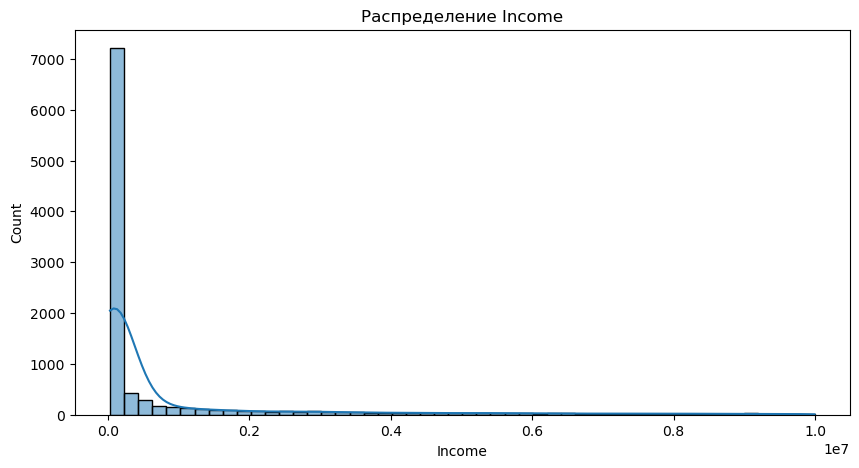

In [3]:
df = pd.read_csv('household_income (1).csv')
print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о данных:")
df.info()
print("\nСтатистика числовых признаков:")
display(df.describe())
print("\nПропуски:")
print(df.isnull().sum())
plt.figure(figsize=(10,5))
sns.histplot(df['Income'], bins=50, kde=True)
plt.title('Распределение Income')
plt.show()

In [7]:
num_features = ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size']
cat_features = ['Education_Level', 'Occupation', 'Location', 'Marital_Status',
                'Employment_Status', 'Homeownership_Status', 'Type_of_Housing',
                'Gender', 'Primary_Mode_of_Transportation']
x = df.drop('Income', axis=1)
y = df['Income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])
x_train_prep = preprocessor.fit_transform(x_train)
x_test_prep = preprocessor.transform(x_test)
print("Размер обучающей матрицы:", x_train_prep.shape)

Размер обучающей матрицы: (8000, 24)


In [8]:
results = {}
lr = LinearRegression()
lr.fit(x_train_prep, y_train)
y_pred_lr = lr.predict(x_test_prep)
results['LinearRegression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}

rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(x_train_prep, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test_prep)
results['RandomForest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
    'best_params': grid_rf.best_params_
}

In [10]:
gb = GradientBoostingRegressor(random_state=42)
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(gb, param_grid_gb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb.fit(x_train_prep, y_train)
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(x_test_prep)
results['GradientBoosting'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'MAE': mean_absolute_error(y_test, y_pred_gb), 
    'R2': r2_score(y_test, y_pred_gb),
    'best_params': grid_gb.best_params_
}

en = ElasticNet(random_state=42)
param_grid_en = {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.2, 0.5, 0.8]}
grid_en = GridSearchCV(en, param_grid_en, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_en.fit(x_train_prep, y_train)
best_en = grid_en.best_estimator_
y_pred_en = best_en.predict(x_test_prep)
results['ElasticNet'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_en)),
    'MAE': mean_absolute_error(y_test, y_pred_en),
    'R2': r2_score(y_test, y_pred_en),
    'best_params': grid_en.best_params_
}

In [11]:
print("=" * 50)
print("Результаты моделей на тестовой выборке")
print("=" * 50)
for name, metrics in results.items():
    print(f"\n{name}:")
    for k, v in metrics.items():
        if k == 'best_params':
            print(f"Лучшие параметры: {v}")
        else:
            print(f" {k}: {v:.4f}")

Результаты моделей на тестовой выборке

LinearRegression:
 RMSE: 1770979.3484
 MAE: 1102165.9760
 R2: 0.0059

RandomForest:
 RMSE: 1757909.2628
 MAE: 1111542.7069
 R2: 0.0205
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

GradientBoosting:
 RMSE: 1758515.3063
 MAE: 1096693.3068
 R2: 0.0198
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}

ElasticNet:
 RMSE: 1770998.2873
 MAE: 1109550.5337
 R2: 0.0058
Лучшие параметры: {'alpha': 1.0, 'l1_ratio': 0.8}


In [12]:
best_model_name = min(results, key=lambda x: results[x]['RMSE'])
best_model_metrics = results[best_model_name]
print("\n" + "=" * 50)
print(f"Лучшая модель: {best_model_name}")
print(f"RMSE: {best_model_metrics['RMSE']:.4f}")
print(f"MAE: {best_model_metrics['MAE']:.4f}")
print(f"R^2: {best_model_metrics['R2']:.4f}")
if 'best_params' in best_model_metrics:
    print(f"Оптимальные гиперпараметры: {best_model_metrics['best_params']}")



Лучшая модель: RandomForest
RMSE: 1757909.2628
MAE: 1111542.7069
R^2: 0.0205
Оптимальные гиперпараметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
if best_model_name == 'RandomForest':
    importances = best_rf.feature_importances_
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
    all_feature_names = num_features + list(cat_names)
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    feat_imp.head(!5).plot(kind='bar')
    plt.title('Топ-15 важнейши

# Выводы

Ключевые выводы по задачам.